# Setting up

In [2]:
import pandas as pd
import numpy as np

home_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/cell_phenotype_testing/"
data_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/celesta/endometrial_test"

# Loading data

In [ ]:
# load all cell phenotype testing files from michelle

# common channels for cell segmentation
with open(f"{home_dir}/common_channels_cell_segmentation.txt", "r") as f:
    lines = f.readlines()
    lines = [line.strip() for line in lines]
common_channels_cell_segmentation = lines
    
# for all patients - need to subset for 3P sample only
metadata_all_samples = pd.read_csv(f"{home_dir}/metadata_all_samples.csv", index_col=0, header=0)

# raw means for 3P sample only
raw_biomarker_means_3P = pd.read_csv(f"{home_dir}/raw_biomarker_means_3P.csv", index_col=0, header=0)

# raw biomarker means for all samples (cell x biomarker mean)
matrix_all_samples = np.load(f"{home_dir}/matrix_all_samples.npy")

# normalized biomarker means for all samples with all markers
matrix_normal = np.load(f"{home_dir}/matrix_normal.npy")

# normalized biomarker means for all samples with only markers used for phenotyping
matrix_normal_filtered_markers = np.load(f"{home_dir}/matrix_normal_filtered_markers.npy")

# Exploring the data

## metadata_all_samples

In [3]:
# for all patients - need to subset for 3P sample only
metadata_all_samples = pd.read_csv(f"{home_dir}/metadata_all_samples.csv", index_col=0, header=0)

print("metadata_all_samples")
print("cells, features:", metadata_all_samples.shape)

# check unique indices
unique_ids = metadata_all_samples["Unnamed: 0"].unique()
print("unique IDs in Unnamed: 0 col:", len(unique_ids))
# check if 0 is there
if 0 in unique_ids:
    print("ID 0 is present in 'Unnamed: 0'.")
else:
    print("ID 0 is NOT present in 'Unnamed: 0'.")
# check if 13643911 is there
if 13643911 in unique_ids:
    print("ID 13643911 is present in 'Unnamed: 0'.")
else:
    print("ID 13643911 is NOT present in 'Unnamed: 0'.")

# check unique cell labels
unique_cell_labels = metadata_all_samples['cell_label'].unique()
print("unique cell labels:", len(unique_cell_labels))

metadata_all_samples

metadata_all_samples
cells, features: (14528644, 13)
unique IDs in Unnamed: 0 col: 13643911
ID 0 is present in 'Unnamed: 0'.
ID 13643911 is NOT present in 'Unnamed: 0'.
unique cell labels: 358


,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type
0,2914138,1,11.185841,2.539823,113.0,49.213203,2.442150,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined)
1,2914139,2,74.119048,2.769841,126.0,46.485281,2.732065,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined)
2,2914140,3,178.849673,2.928105,153.0,53.313708,3.004659,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined)
3,2914141,4,239.702703,2.175676,74.0,36.142136,2.215427,7680,12800,20230922-7331-1J_Scan1,ecad-_,15,Stromal cells (undefined)
4,2914142,5,200.729730,4.533784,148.0,45.071068,1.498154,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14528639,13643906,162,83.451389,240.567130,432.0,92.426407,1.902631,39936,2816,20231019-4475-1E_Scan2,ecad+_,5,Tumor cells
14528640,13643907,163,69.078431,245.856209,153.0,46.384776,1.159109,39936,2816,20231019-4475-1E_Scan2,ecad+_,27,Tumor cells
14528641,13643908,164,17.588517,248.124402,209.0,55.556349,1.446012,39936,2816,20231019-4475-1E_Scan2,ecad+_,5,Tumor cells
14528642,13643909,165,61.297297,250.467181,259.0,93.941125,2.492176,39936,2816,20231019-4475-1E_Scan2,ecad+_,27,Tumor cells


In [10]:
metadata_all_samples["absolute_x"] = metadata_all_samples["tile_w"] + metadata_all_samples["centroid_x"]
metadata_all_samples["absolute_y"] = metadata_all_samples["tile_h"] + metadata_all_samples["centroid_y"]
metadata_all_samples

,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type,absolute_x,absolute_y
0,2914138,1,11.185841,2.539823,113.0,49.213203,2.442150,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined),12811.185841,7682.539823
1,2914139,2,74.119048,2.769841,126.0,46.485281,2.732065,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined),12874.119048,7682.769841
2,2914140,3,178.849673,2.928105,153.0,53.313708,3.004659,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined),12978.849673,7682.928105
3,2914141,4,239.702703,2.175676,74.0,36.142136,2.215427,7680,12800,20230922-7331-1J_Scan1,ecad-_,15,Stromal cells (undefined),13039.702703,7682.175676
4,2914142,5,200.729730,4.533784,148.0,45.071068,1.498154,7680,12800,20230922-7331-1J_Scan1,ecad-_,2,Stromal cells (undefined),13000.729730,7684.533784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14528639,13643906,162,83.451389,240.567130,432.0,92.426407,1.902631,39936,2816,20231019-4475-1E_Scan2,ecad+_,5,Tumor cells,2899.451389,40176.567130
14528640,13643907,163,69.078431,245.856209,153.0,46.384776,1.159109,39936,2816,20231019-4475-1E_Scan2,ecad+_,27,Tumor cells,2885.078431,40181.856209
14528641,13643908,164,17.588517,248.124402,209.0,55.556349,1.446012,39936,2816,20231019-4475-1E_Scan2,ecad+_,5,Tumor cells,2833.588517,40184.124402
14528642,13643909,165,61.297297,250.467181,259.0,93.941125,2.492176,39936,2816,20231019-4475-1E_Scan2,ecad+_,27,Tumor cells,2877.297297,40186.467181


In [5]:
# get all cell types
cell_types = metadata_all_samples['cell_type'].unique().tolist()
print("cell types:", len(cell_types), "\n")
for i, cell_type in enumerate(cell_types, start=1):
    print(i, cell_type)

cell types: 15 

1 Stromal cells (undefined)
2 Endothelial cells
3 Tumor cells
4 Cytotoxic T cells
5 Macrophages (CD163-)
6 T cells (other)
7 Helper T cells
8 Neutrophils
9 Macrophages (CD163+)
10 B cells
11 CD4+ and CD8+ T cells
12 CD20+ and CD8+ cells
13 CD20+ and CD4+ cells
14 Artifact
15 CD20+ and CD3e+ cells


In [3]:
print("all markers:", len(common_channels_cell_segmentation), "\n")
for i, channel in enumerate(common_channels_cell_segmentation, start=1):
    print(i, channel)

all markers: 31 

1 DAPI
2 MPO
3 E-cadherin
4 PD-L1
5 CD163
6 PD-1
7 CD47
8 GAL3
9 PARP1
10 LAG3
11 CD4
12 PI3KCA
13 TIM3
14 CD68
15 ER
16 PR
17 MSH2
18 CD8
19 MSH6
20 b-Catenin1
21 HLA-ABC
22 MLH1
23 Ki67
24 CD20
25 ARID1A
26 IFNG
27 CD31
28 PMS
29 CD44
30 Pan-Cytokeratin
31 CD3e


In [3]:
print("matrix_all_samples")
print("cells, markers:", matrix_all_samples.shape)
print(matrix_all_samples[:5, :5])

matrix_all_samples
cells, markers: (14528644, 31)
[[3.08761063e+01 2.30088502e-01 7.07964599e-02 2.94690275e+00
  8.84955749e-03]
 [2.76111107e+01 3.17460328e-01 7.93650821e-02 2.21428561e+00
  7.14285746e-02]
 [2.63660126e+01 8.69281054e-01 1.63398698e-01 1.76470590e+00
  7.84313753e-02]
 [5.25810814e+01 6.62162185e-01 2.02702701e-01 4.78378391e+00
  1.35135138e-02]
 [2.65608101e+01 1.62162155e-01 2.56756753e-01 2.58108115e+00
  1.68918923e-01]]


In [4]:
# 31 markers
print("matrix_normal")
print("cells, markers:", matrix_normal.shape)
full_markers = matrix_normal[:31, :1]
print(full_markers)

matrix_normal
cells, markers: (13631411, 31)
[[-0.99159694]
 [-0.78349775]
 [ 0.34359443]
 [-0.15179885]
 [-0.22739182]
 [-0.37321753]
 [-0.7607817 ]
 [-1.00027645]
 [-0.3819358 ]
 [ 0.06026819]
 [-0.86330024]
 [ 0.43912419]
 [ 0.82135222]
 [-0.20979465]
 [-0.52093587]
 [-0.79988931]
 [-0.88855443]
 [-0.31656011]
 [-0.47630608]
 [-0.78499821]
 [ 0.08071388]
 [-0.96255442]
 [-0.95133935]
 [-0.76022155]
 [-0.50820232]
 [-0.65044935]
 [-0.76845543]
 [-0.69408014]
 [-1.05280744]
 [-0.34296436]
 [-0.77406126]]


In [5]:
# only 10 markers used for phenotyping
print("matrix_normal_filtered_markers")
print("cells, markers:", matrix_normal_filtered_markers.shape)
subset_markers = matrix_normal_filtered_markers[:10, :1]
print(subset_markers)

matrix_normal_filtered_markers
cells, markers: (13631411, 10)
[[-0.99159694]
 [-0.78349775]
 [ 0.34359443]
 [-0.15179885]
 [-0.22739182]
 [-0.37321753]
 [-0.7607817 ]
 [-1.00027645]
 [-0.3819358 ]
 [ 0.06026819]]


In [8]:
# 10 biomarkers
filtered_markers = ['DAPI', 'MPO', 'Ecadherin', 'CD163', 'CD4', 'CD68', 'CD8', 'CD20', 'CD31', 'CD3e']
marker_list = [col for col in raw_biomarker_means_3P.columns if col != 'roi']

filtered_indices = [i for i, marker in enumerate(marker_list) if marker in filtered_markers]
print(filtered_indices)

[0, 1, 2, 4, 10, 13, 17, 23, 26, 30]


## matrix_all_samples_filtered_markers

In [10]:
# create and save matrix_all_samples_filtered_markers
matrix_all_samples_filtered_markers = matrix_all_samples[:, filtered_indices]
np.save(f'{data_dir}/matrix_all_samples_filtered_markers.npy', matrix_all_samples_filtered_markers)
print("matrix_all_samples_filtered_markers")
print("cells, markers:", matrix_all_samples_filtered_markers.shape)
print(matrix_all_samples_filtered_markers[:5, :5])

matrix_all_samples_filtered_markers
cells, markers: (14528644, 10)
[[3.08761063e+01 2.30088502e-01 7.07964599e-02 8.84955749e-03
  3.04424787e+00]
 [2.76111107e+01 3.17460328e-01 7.93650821e-02 7.14285746e-02
  2.70634913e+00]
 [2.63660126e+01 8.69281054e-01 1.63398698e-01 7.84313753e-02
  4.77777767e+00]
 [5.25810814e+01 6.62162185e-01 2.02702701e-01 1.35135138e-02
  3.14864874e+00]
 [2.65608101e+01 1.62162155e-01 2.56756753e-01 1.68918923e-01
  3.60810804e+00]]


## df_normal_filtered_markers

Ask Michelle how the indexing works for this!

In [38]:
# create df from matrix_normal_filtered_markers

filtered_markers = ['DAPI', 'MPO', 'Ecadherin', 'CD163', 'CD4', 'CD68', 'CD8', 'CD20', 'CD31', 'CD3e']
df_normal_filtered_markers = pd.DataFrame(matrix_normal_filtered_markers, columns=filtered_markers)
df_normal_filtered_markers.reset_index(drop=True, inplace=True)
print(df_normal_filtered_markers.shape)
df_normal_filtered_markers

(13631411, 10)


,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
0,-0.991597,-0.413055,-0.818001,-0.051155,-0.125350,-0.087191,-0.064584,0.0,-0.404297,-0.153236
1,-0.783498,-0.411194,-0.818706,-0.051155,-0.125350,-0.087191,-0.064584,0.0,-0.428029,-0.153236
2,0.343594,-0.411293,-0.816110,-0.051155,-0.125350,-0.087191,2.196744,0.0,1.639804,1.687798
3,-0.151799,-0.411226,-0.812980,-0.051155,-0.125350,-0.087191,-0.064584,0.0,-0.299788,-0.153236
4,-0.227392,-0.381874,-0.820114,-0.051155,-0.125350,-0.087191,-0.064584,0.0,-0.335899,-0.153236
...,...,...,...,...,...,...,...,...,...,...
13631406,-0.036771,-0.135696,0.063515,-0.079962,-0.117631,-0.110249,-0.118168,0.0,-0.099347,-0.132778
13631407,0.451922,-0.130146,0.713549,-0.079962,-0.117631,-0.110249,-0.118168,0.0,-0.123534,-0.132778
13631408,0.164487,-0.130080,0.236231,-0.079962,-0.117631,-0.110249,-0.118168,0.0,-0.164101,-0.132778
13631409,0.340878,-0.131281,0.264997,-0.079962,-0.117631,-0.110249,-0.118168,0.0,-0.025366,-0.132778


## df_raw_filtered_markers

In [5]:
# create df from matrix_all_samples_filtered_markers

matrix_all_samples_filtered_markers = np.load(f'{data_dir}/matrix_all_samples_filtered_markers.npy')
filtered_markers = ['DAPI', 'MPO', 'Ecadherin', 'CD163', 'CD4', 'CD68', 'CD8', 'CD20', 'CD31', 'CD3e']
df_raw_filtered_markers = pd.DataFrame(matrix_all_samples_filtered_markers, columns=filtered_markers)
# df_raw_filtered_markers.index = metadata_all_samples["Unnamed: 0"].values  # OPTION 1: add index col from metadata_all_samples["Unnamed: 0"]
df_raw_filtered_markers.reset_index(drop=True, inplace=True)  # OPTION 2: reset index from 0
print(df_raw_filtered_markers.shape)
df_raw_filtered_markers

(14528644, 10)


,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
0,30.876106,0.230089,0.070796,0.008850,3.044248,3.274336,0.008850,1.530973,0.079646,1.663717
1,27.611111,0.317460,0.079365,0.071429,2.706349,2.531746,0.007937,1.198413,0.134921,0.912698
2,26.366013,0.869281,0.163399,0.078431,4.777778,3.967320,0.000000,1.339869,0.202614,1.215686
3,52.581081,0.662162,0.202703,0.013514,3.148649,3.054054,0.108108,1.662162,0.851351,2.229730
4,26.560810,0.162162,0.256757,0.168919,3.608108,2.702703,1.168919,1.121622,0.081081,3.520270
...,...,...,...,...,...,...,...,...,...,...
14528639,20.363426,0.046296,6.500000,0.000000,2.363426,2.625000,0.000000,2.912037,0.375000,0.541667
14528640,24.699347,0.104575,11.614379,0.000000,2.228758,2.666667,0.000000,1.993464,0.333333,0.555556
14528641,22.100479,0.105263,7.755981,0.000000,2.569378,2.717703,0.000000,1.574163,0.263158,0.665072
14528642,23.667953,0.092664,7.969112,0.000000,2.567568,2.930502,0.000000,1.648649,0.501930,0.745174


## metadata_3P

In [23]:
# subset to 3p metadata only
metadata_3P = metadata_all_samples[metadata_all_samples['slide_id'].str.contains('3P', na=False)]

print("metadata_3P")
print("cells, features:", metadata_3P.shape)
print("unique IDs in Unnamed: 0 col:", len(metadata_3P["Unnamed: 0"].unique()))

# check unique cell labels
unique_cell_labels = metadata_3P['cell_label'].unique()
print("unique cell labels:", len(unique_cell_labels))

metadata_3P.to_csv(f"{data_dir}/metadata_3P.csv", index=False)
metadata_3P.head()

metadata_3P
cells, features: (1204865, 15)
unique IDs in Unnamed: 0 col: 1204865
unique cell labels: 341


,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type,absolute_x,absolute_y
10699219,9814486,1,230.081633,3.923469,196.0,60.384776,2.134629,1024,19712,20231003-2630-3P_Scan1,ecad-_,18,Stromal cells (undefined),19942.081633,1027.923469
10699220,9814487,2,204.405286,5.475771,227.0,60.970563,1.626469,1024,19712,20231003-2630-3P_Scan1,ecad-_,3,Stromal cells (undefined),19916.405286,1029.475771
10699221,9814488,3,217.459350,12.573171,246.0,56.526912,1.040366,1024,19712,20231003-2630-3P_Scan1,ecad-_,21,T cells (other),19929.459350,1036.573171
10699222,9814489,4,237.955752,14.482301,226.0,57.870058,1.052086,1024,19712,20231003-2630-3P_Scan1,ecad-_,1,Stromal cells (undefined),19949.955752,1038.482301
10699223,9814490,5,249.485342,12.387622,307.0,80.384776,2.293335,1024,19712,20231003-2630-3P_Scan1,ecad-_,1,Stromal cells (undefined),19961.485342,1036.387622


In [7]:
# get all cell types in 3P
cell_types = metadata_3P['cell_type'].unique().tolist()
print("cell types:", len(cell_types), "\n")
for i, cell_type in enumerate(cell_types, start=1):
    print(i, cell_type)

cell types: 13 

1 Stromal cells (undefined)
2 T cells (other)
3 Tumor cells
4 Neutrophils
5 Endothelial cells
6 Helper T cells
7 Cytotoxic T cells
8 Macrophages (CD163-)
9 B cells
10 Macrophages (CD163+)
11 Artifact
12 CD20+ and CD3e+ cells
13 CD20+ and CD4+ cells


## coords_3P

In [24]:
# make coords_df for 3P to make imaging_data file
# X, Y, markers = centroid_x, centroid_y, 

coords_3P = metadata_3P[['absolute_x', 'absolute_y']].copy()
coords_3P = coords_3P.rename(columns={'absolute_x': 'X', 'absolute_y': 'Y'})

print("coords_3P")
print("cells, XY", coords_3P.shape)
coords_3P.head()

coords_3P
cells, XY (1204865, 2)


,X,Y
10699219,19942.081633,1027.923469
10699220,19916.405286,1029.475771
10699221,19929.459350,1036.573171
10699222,19949.955752,1038.482301
10699223,19961.485342,1036.387622


In [7]:
# should be 1204865 rows for 3P (as we saw above)
print("raw_biomarker_means_3P")
print("cells, markers:", raw_biomarker_means_3P.shape)
for i, col in enumerate(raw_biomarker_means_3P.columns, start=-1):
    print(i, col)
    
raw_biomarker_means_3P.head()

raw_biomarker_means_3P
cells, markers: (1204865, 32)
-1 roi
0 DAPI
1 MPO
2 Ecadherin
3 PDL1
4 CD163
5 PD1
6 CD47
7 GAL3
8 PARP1
9 LAG3
10 CD4
11 PI3KCA
12 TIM3
13 CD68
14 ER
15 PR
16 MSH2
17 CD8
18 MSH6
19 bCatenin1
20 HLAABC
21 MLH1
22 Ki67
23 CD20
24 ARID1A
25 IFNG
26 CD31
27 PMS
28 CD44
29 PanCytokeratin
30 CD3e


,roi,DAPI,MPO,Ecadherin,PDL1,CD163,PD1,CD47,GAL3,PARP1,...,MLH1,Ki67,CD20,ARID1A,IFNG,CD31,PMS,CD44,PanCytokeratin,CD3e
object,,,,,,,,,,,,,,,,,,,,,
1,1231681,23.520409,2.408163,0.163265,2.122449,0.000000,0.969388,3.408163,25.647959,8.469388,...,1.576531,0.035714,1.260204,1.418367,1.158163,0.357143,1.025510,0.188776,8.234694,1.397959
2,1231681,18.004406,0.000000,0.000000,0.035242,0.000000,0.008811,0.079295,2.519824,0.000000,...,0.000000,0.000000,0.215859,0.000000,0.083700,0.017621,0.000000,0.000000,1.497797,0.334802
3,1231681,19.109756,1.524390,0.024390,1.138211,0.000000,0.841463,2.378049,10.288618,10.707317,...,2.284553,0.048780,0.739837,4.004065,1.126016,0.186992,1.613821,0.849594,2.121951,18.430895
4,1231681,25.548672,6.451327,0.199115,2.800885,0.000000,1.119469,3.995575,33.690266,55.176991,...,3.800885,1.057522,1.455752,3.482301,1.402655,0.323009,1.703540,0.469027,7.508850,1.969027
5,1231681,26.162867,3.449511,1.902280,1.475570,0.140065,1.071661,5.133551,39.625408,55.078175,...,6.358306,15.934854,1.201954,5.726384,1.622150,0.830619,4.651466,7.117264,5.879479,1.872964


## metadata_1T

In [25]:
# subset to 1t metadata only
metadata_1T = metadata_all_samples[metadata_all_samples['slide_id'].str.contains('1T', na=False)]

# Check result
print("metadata_1T")
print("cells, features:", metadata_1T.shape)
print("unique IDs in Unnamed: 0 col:", len(metadata_1T["Unnamed: 0"].unique()))

# check unique cell labels
unique_cell_labels = metadata_1T['cell_label'].unique()
print("unique cell labels:", len(unique_cell_labels))

# show rows with duplicated labels
duplicated_labels = metadata_1T['cell_label'][metadata_1T['cell_label'].duplicated(keep=False)]
duplicated_rows = metadata_1T[metadata_1T['cell_label'].isin(duplicated_labels)]
duplicated_rows.sort_values(by='cell_label').head(10)

# Find duplicated centroid pairs
duplicated_coords = metadata_1T[metadata_1T.duplicated(subset=['centroid_x', 'centroid_y'], keep=False)]

# Display number and preview
print(f"Number of duplicated (centroid_x, centroid_y) pairs: {duplicated_coords.shape[0]}")
print(duplicated_coords[['cell_label', 'centroid_x', 'centroid_y']].sort_values(by=['centroid_x', 'centroid_y']).head())

metadata_1T.to_csv(f"{data_dir}/metadata_1T.csv", index=False)
metadata_1T.head()

metadata_1T
cells, features: (22730, 15)
unique IDs in Unnamed: 0 col: 22730
unique cell labels: 263
Number of duplicated (centroid_x, centroid_y) pairs: 2
          cell_label  centroid_x  centroid_y
13671239         125    1.333333  200.380952
13672825         120    1.333333  200.380952


,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type,absolute_x,absolute_y
13652415,12767682,1,183.119658,2.683761,117.0,44.485281,2.655791,512,11008,20231012-3535-1T_Scan2,ecad-_,0,Artifact,11191.119658,514.683761
13652416,12767683,2,39.495690,6.896552,464.0,89.112698,1.951142,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11047.495690,518.896552
13652417,12767684,3,8.777589,13.743633,589.0,114.662951,1.902386,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11016.777589,525.743633
13652418,12767685,4,225.250000,18.339695,524.0,87.112698,1.666739,512,11008,20231012-3535-1T_Scan2,ecad-_,0,Artifact,11233.250000,530.339695
13652419,12767686,5,40.524717,29.258487,1679.0,183.273124,1.387644,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11048.524717,541.258487


## coords_1T

In [26]:
# make coords_df for 1T to make imaging_data file
# X, Y, markers = centroid_x, centroid_y, 

coords_1T = metadata_1T[['absolute_x', 'absolute_y']].copy()
coords_1T = coords_1T.rename(columns={'absolute_x': 'X', 'absolute_y': 'Y'})

# coords_1T.to_csv(f"{data_dir}/coords_1T.csv", index=True)

print("coords_1T")
print("cells, XY", coords_1T.shape)
coords_1T.head()

coords_1T
cells, XY (22730, 2)


,X,Y
13652415,11191.119658,514.683761
13652416,11047.495690,518.896552
13652417,11016.777589,525.743633
13652418,11233.250000,530.339695
13652419,11048.524717,541.258487


# prior_marker_info_endometrial

In [28]:
# load prior_marker_info
prior_marker_info_endometrial = pd.read_csv(f"{data_dir}/prior_marker_info_endometrial.csv", header=0)
print("prior_marker_info_endometrial")
print("cell types, marker probs:", prior_marker_info_endometrial.shape)
prior_marker_info_endometrial

prior_marker_info_endometrial
cell types, marker probs: (10, 12)


,Column 1,Lineage_level,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
0,Stromal cells (undefined),1_0_1,1,0,0.0,0,0,0,0,0,0,0
1,Endothelial cells,1_0_2,1,0,0.0,0,0,0,0,0,1,0
2,Tumor cells,1_0_3,1,0,1.0,0,0,0,0,0,0,0
3,Macrophages (CD163-),2_1_4,1,0,NaN,0,0,1,0,0,0,0
4,Macrophages (CD163+),2_1_5,1,0,NaN,1,0,1,0,0,0,0
5,Neutrophils,2_1_6,1,1,NaN,0,0,0,0,0,0,0
6,B cells,2_1_7,1,0,NaN,0,0,0,0,1,0,0
7,T cells (other),2_1_8,1,0,NaN,0,0,0,0,0,0,1
8,Cytotoxic T cells,3_8_9,1,0,NaN,0,0,0,1,0,0,1
9,Helper T cells,3_8_10,1,0,NaN,0,1,0,0,0,0,1


In [12]:
# drop cd20
prior_marker_info_3P_noCD20 = prior_marker_info_3P.drop(columns="CD20")
prior_marker_info_3P_noCD20.to_csv(f"{data_dir}/prior_marker_info_3P_noCD20.csv", index=False)
prior_marker_info_3P_noCD20.head()

,Column 1,Lineage_level,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD31,CD3e
0,Stromal cells (undefined),1_0_1,1,0,0,0,0,0,0,0,0
1,Endothelial cells,1_0_2,1,0,0,0,0,0,0,1,0
2,Tumor cells,1_0_3,1,0,1,0,0,0,0,0,0
3,Macrophages (CD163-),2_1_4,1,0,0,0,0,1,0,0,0
4,Macrophages (CD163+),2_1_5,1,0,0,1,0,1,0,0,0


# Creating imaging_data_3P

Rows are cells, columns are X, Y, biomarker_means (raw/normalized).

In [27]:
import pandas as pd
import numpy as np

home_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/cell_phenotype_testing/"
data_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/celesta/endometrial_test"

## imaging_data_3P_raw

In [57]:
# check raw_biomarker_means_3P
raw_biomarker_means_3P

,roi,DAPI,MPO,Ecadherin,PDL1,CD163,PD1,CD47,GAL3,PARP1,...,MLH1,Ki67,CD20,ARID1A,IFNG,CD31,PMS,CD44,PanCytokeratin,CD3e
object,,,,,,,,,,,,,,,,,,,,,
1,1231681,23.520409,2.408163,0.163265,2.122449,0.000000,0.969388,3.408163,25.647959,8.469388,...,1.576531,0.035714,1.260204,1.418367,1.158163,0.357143,1.025510,0.188776,8.234694,1.397959
2,1231681,18.004406,0.000000,0.000000,0.035242,0.000000,0.008811,0.079295,2.519824,0.000000,...,0.000000,0.000000,0.215859,0.000000,0.083700,0.017621,0.000000,0.000000,1.497797,0.334802
3,1231681,19.109756,1.524390,0.024390,1.138211,0.000000,0.841463,2.378049,10.288618,10.707317,...,2.284553,0.048780,0.739837,4.004065,1.126016,0.186992,1.613821,0.849594,2.121951,18.430895
4,1231681,25.548672,6.451327,0.199115,2.800885,0.000000,1.119469,3.995575,33.690266,55.176991,...,3.800885,1.057522,1.455752,3.482301,1.402655,0.323009,1.703540,0.469027,7.508850,1.969027
5,1231681,26.162867,3.449511,1.902280,1.475570,0.140065,1.071661,5.133551,39.625408,55.078175,...,6.358306,15.934854,1.201954,5.726384,1.622150,0.830619,4.651466,7.117264,5.879479,1.872964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204861,1231681,24.869230,0.723077,27.707693,0.607692,0.000000,0.430769,3.900000,45.569229,44.715385,...,6.238461,0.500000,2.261539,6.884615,1.023077,0.638462,4.000000,2.523077,7.784616,2.261539
1204862,1231681,25.460938,1.203125,37.390625,1.328125,0.000000,0.796875,25.359375,173.960938,28.992188,...,8.070312,0.492188,2.046875,6.453125,1.828125,0.609375,4.554688,0.953125,18.242188,3.539062
1204863,1231681,21.203007,0.654135,29.563910,0.593985,0.000000,0.458647,29.390978,148.796997,4.398496,...,5.315790,0.488722,1.857143,1.804511,2.593985,0.593985,1.902256,1.045113,24.639097,2.360902


In [28]:
# coords_3P + df_raw_filtered_markers
imaging_data_3P_raw = coords_3P.join(df_raw_filtered_markers, how="left")
print("imaging_data_3P_raw")
print("cells, features:", imaging_data_3P_raw.shape)
imaging_data_3P_raw.to_csv(f"{data_dir}/imaging_data_3P_raw.csv", index=False)
imaging_data_3P_raw

imaging_data_3P_raw
cells, features: (1204865, 12)


,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
10699219,19942.081633,1027.923469,23.520409,2.408163,0.163265,0.000000,1.540816,2.724490,0.000000,1.260204,0.357143,1.397959
10699220,19916.405286,1029.475771,18.004406,0.000000,0.000000,0.000000,0.321586,0.440529,0.000000,0.215859,0.017621,0.334802
10699221,19929.459350,1036.573171,19.109756,1.524390,0.024390,0.000000,10.735772,2.296748,0.000000,0.739837,0.186992,18.430895
10699222,19949.955752,1038.482301,25.548672,6.451327,0.199115,0.000000,1.964602,3.663717,0.000000,1.455752,0.323009,1.969027
10699223,19961.485342,1036.387622,26.162867,3.449511,1.902280,0.140065,1.540717,3.280130,0.000000,1.201954,0.830619,1.872964
...,...,...,...,...,...,...,...,...,...,...,...,...
11904079,22633.507692,36603.184615,24.869230,0.723077,27.707693,0.000000,3.092308,5.400000,0.000000,2.261539,0.638462,2.261539
11904080,22545.562500,36603.804688,25.460938,1.203125,37.390625,0.000000,2.093750,5.656250,0.000000,2.046875,0.609375,3.539062
11904081,22584.541353,36602.857143,21.203007,0.654135,29.563910,0.000000,2.187970,8.819549,0.000000,1.857143,0.593985,2.360902
11904082,22727.800000,36604.303448,24.248276,0.717241,51.813793,0.000000,1.648276,7.800000,1.200000,1.800000,0.675862,4.572414


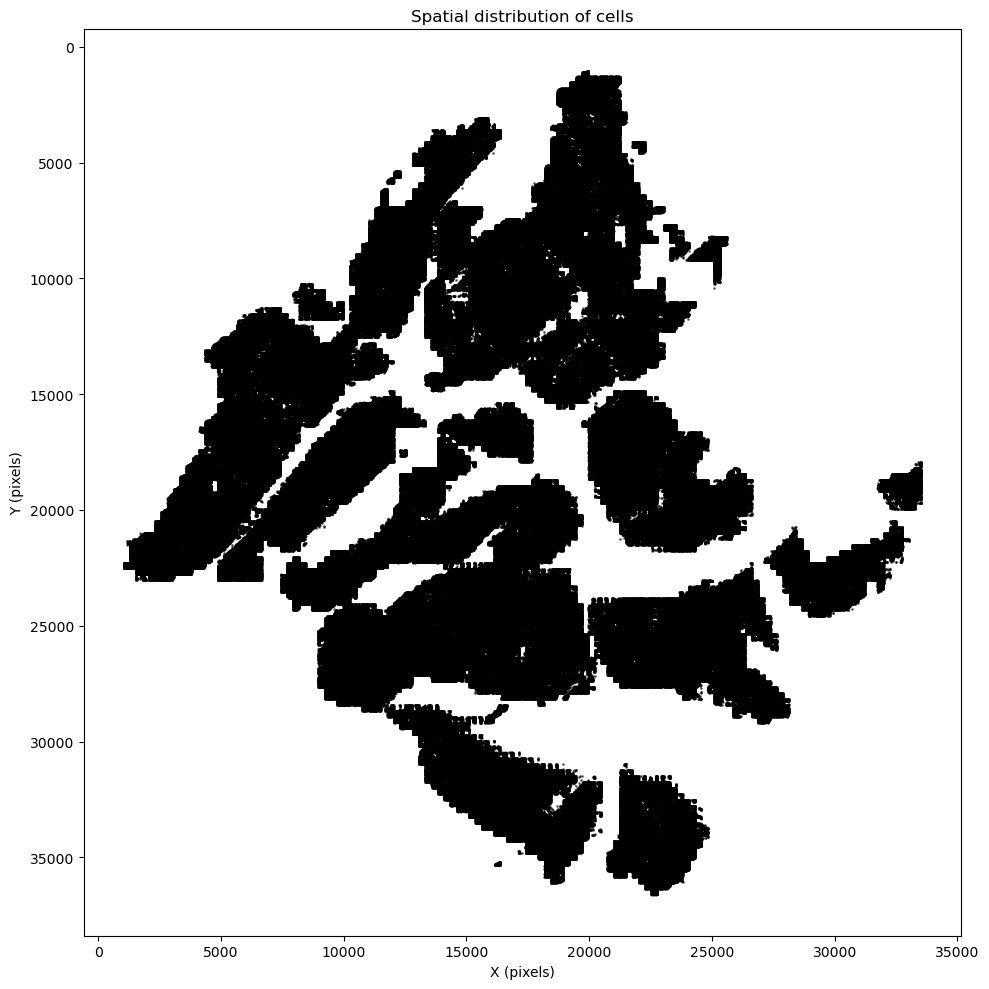

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv(f"{data_dir}/imaging_data_3P_raw.csv")  # Or use your DataFrame directly if already loaded

# Plot X vs Y
plt.figure(figsize=(10, 10))
plt.scatter(df['X'], df['Y'], s=1, alpha=0.5, c='black')  # small dots, slightly transparent
plt.gca().invert_yaxis()  # optional: invert Y-axis to match image coordinate system
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial distribution of cells")
plt.tight_layout()
plt.show()

## imaging_data_3P_normal

In [73]:
# coords_3P + df_normal_filtered_markers
imaging_data_3P_normal = coords_3P.join(df_normal_filtered_markers, how="left")
print("imaging_data_3P_normal")
print("cells, features:", imaging_data_3P_normal.shape)
imaging_data_3P_normal

imaging_data_3P_normal
cells, features: (1204865, 13)
unique cell labels: 341


,cell_label,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
10699219,1,230.081633,3.923469,-0.605457,-0.185792,0.309090,-0.048151,-0.110976,-0.075550,-0.111902,-0.066741,-0.199616,-0.213092
10699220,2,204.405286,5.475771,1.005072,-0.248990,0.004289,-0.048151,-0.110976,-0.075550,-0.111902,-0.066741,-0.165759,-0.213092
10699221,3,217.459350,12.573171,-0.676968,-0.225886,1.036583,-0.048151,-0.110976,-0.075550,-0.111902,-0.066741,-0.128835,-0.213092
10699222,4,237.955752,14.482301,-0.464954,-0.215331,-0.024155,-0.048151,-0.110976,-0.075550,-0.111902,-0.066741,-0.165210,-0.213092
10699223,5,249.485342,12.387622,-0.862733,-0.212793,-0.328725,-0.048151,-0.110976,-0.075550,-0.111902,-0.066741,-0.200951,-0.213092
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11904079,236,105.507692,251.184615,-0.574474,-0.148097,1.994867,-0.039861,-0.120548,-0.157073,-0.071382,-0.042973,-0.165508,-0.171932
11904080,237,17.562500,251.804688,0.047326,-0.128248,0.295779,-0.039861,-0.120548,-0.157073,-0.071382,-0.042973,-0.216967,-0.171932
11904081,238,56.541353,250.857143,-0.415921,0.892857,-0.853303,-0.039861,-0.120548,-0.157073,-0.071382,-0.042973,-0.037732,-0.171932
11904082,239,199.800000,252.303448,-0.503937,-0.137178,-0.339527,-0.039861,-0.120548,-0.157073,-0.071382,-0.042973,-0.189702,-0.171932


In [71]:
# check if any cols are all 0
all_zero_cols = imaging_data_3P_normal.columns[(imaging_data_3P_normal == 0).all()]

if len(all_zero_cols) > 0:
    print("Columns that are all zeros:")
    print(all_zero_cols.tolist())
else:
    print("No columns are entirely zeros.")

No columns are entirely zeros.


In [9]:
# CD20 errors every time we run celesta because value is always 0
print(imaging_data_3P_normal["CD20"].unique())

[0.]


In [10]:
# let's remove cd20 from imaging_data_3P_normal
imaging_data_3P_normal_noCD20 = imaging_data_3P_normal.drop(columns="CD20")
imaging_data_3P_normal_noCD20.to_csv(f"{data_dir}/imaging_data_3P_normal_noCD20.csv", index=False)
imaging_data_3P_normal_noCD20.head()

,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD31,CD3e
0,230.081633,3.923469,-0.991597,-0.413055,-0.818001,-0.051155,-0.12535,-0.087191,-0.064584,-0.404297,-0.153236
1,204.405286,5.475771,-0.783498,-0.411194,-0.818706,-0.051155,-0.12535,-0.087191,-0.064584,-0.428029,-0.153236
2,217.459350,12.573171,0.343594,-0.411293,-0.816110,-0.051155,-0.12535,-0.087191,2.196744,1.639804,1.687798
3,237.955752,14.482301,-0.151799,-0.411226,-0.812980,-0.051155,-0.12535,-0.087191,-0.064584,-0.299788,-0.153236
4,249.485342,12.387622,-0.227392,-0.381874,-0.820114,-0.051155,-0.12535,-0.087191,-0.064584,-0.335899,-0.153236


# Creating imaging_data_1T

## imaging_data_1T_raw

In [30]:
# coords_1T + df_raw_filtered_markers
imaging_data_1T_raw = coords_1T.join(df_raw_filtered_markers, how="left")
print("imaging_data_1T_raw")
print("cells, features:", imaging_data_1T_raw.shape)
imaging_data_1T_raw.to_csv(f"{data_dir}/imaging_data_1T_raw.csv", index=False)
imaging_data_1T_raw

imaging_data_1T_raw
cells, features: (22730, 12)


,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
13652415,11191.119658,514.683761,7.427351,0.025641,0.222222,0.000000,0.059829,0.128205,0.008547,0.717949,0.068376,0.059829
13652416,11047.495690,518.896552,10.739224,0.084052,0.696121,0.002155,0.079741,0.237069,0.002155,1.299569,0.239224,0.081897
13652417,11016.777589,525.743633,11.005094,0.100170,0.699491,0.005093,0.052632,0.191851,0.006791,1.344652,0.273345,0.106961
13652418,11233.250000,530.339695,7.826336,0.095420,0.440840,0.011450,0.055344,0.265267,0.009542,0.866412,0.097328,0.083969
13652419,11048.524717,541.258487,10.374628,0.072662,0.653961,0.016081,0.070876,0.201310,0.009529,1.202502,0.164979,0.082787
...,...,...,...,...,...,...,...,...,...,...,...,...
13675140,16462.903084,5199.337004,26.718061,0.127753,3.165198,0.000000,1.290749,2.151982,0.000000,1.416300,0.211454,1.949339
13675141,16479.093407,5205.637363,14.170330,0.000000,0.093407,0.000000,0.653846,0.692308,0.000000,0.901099,0.010989,0.181319
13675142,16408.976891,5206.962185,16.762606,0.071429,9.760504,0.000000,2.069328,2.661765,0.000000,1.186975,0.128151,1.306723
13675143,16439.907767,5211.461165,13.300971,0.315534,0.000000,0.000000,0.315534,0.490291,0.000000,0.830097,0.024272,0.407767


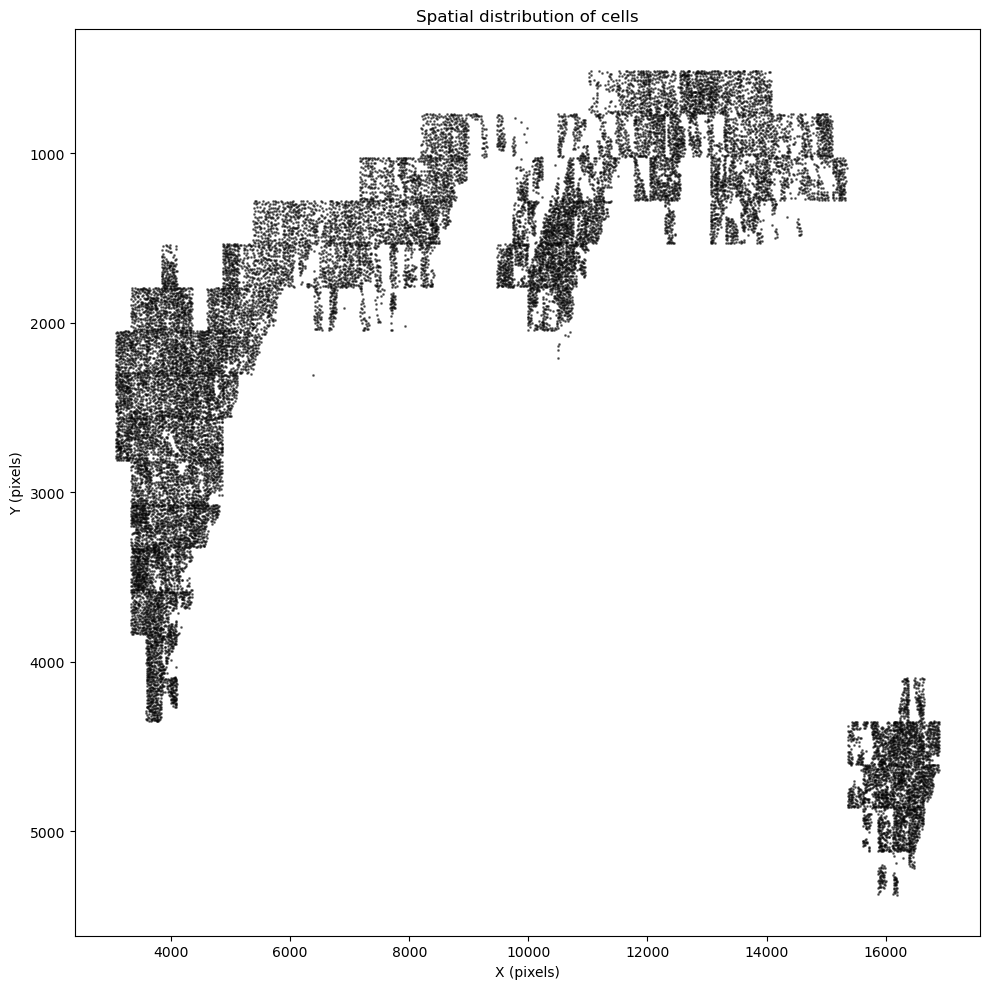

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv(f"{data_dir}/imaging_data_1T_raw.csv")  # Or use your DataFrame directly if already loaded

# Plot X vs Y
plt.figure(figsize=(10, 10))
plt.scatter(df['X'], df['Y'], s=1, alpha=0.5, c='black')  # small dots, slightly transparent
plt.gca().invert_yaxis()  # optional: invert Y-axis to match image coordinate system
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial distribution of cells")
plt.tight_layout()
plt.show()

## imaging_data_1T_normal

In [ ]:
# coords_1T + df_normal_filtered_markers


# Comparing CELESTA to manual phenotyping

In [1]:
import pandas as pd
import numpy as np

home_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/cell_phenotype_testing/"
data_dir = "/gpfs/home/yb2612/yb2612_fenyo/data/celesta/endometrial_test"

In [2]:
import pandas as pd
metadata_1T = pd.read_csv(f"{data_dir}/metadata_1T.csv")
metadata_1T

,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type,absolute_x,absolute_y
0,12767682,1,183.119658,2.683761,117.0,44.485281,2.655791,512,11008,20231012-3535-1T_Scan2,ecad-_,0,Artifact,11191.119658,514.683761
1,12767683,2,39.495690,6.896552,464.0,89.112698,1.951142,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11047.495690,518.896552
2,12767684,3,8.777589,13.743633,589.0,114.662951,1.902386,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11016.777589,525.743633
3,12767685,4,225.250000,18.339695,524.0,87.112698,1.666739,512,11008,20231012-3535-1T_Scan2,ecad-_,0,Artifact,11233.250000,530.339695
4,12767686,5,40.524717,29.258487,1679.0,183.273124,1.387644,512,11008,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),11048.524717,541.258487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22725,12790407,18,78.903084,79.337004,454.0,82.012193,1.264144,5120,16384,20231012-3535-1T_Scan2,ecad-_,16,Tumor cells,16462.903084,5199.337004
22726,12790408,19,95.093407,85.637363,182.0,49.455844,1.260619,5120,16384,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),16479.093407,5205.637363
22727,12790409,20,24.976891,86.962185,476.0,79.012193,1.159523,5120,16384,20231012-3535-1T_Scan2,ecad-_,25,Tumor cells,16408.976891,5206.962185
22728,12790410,21,55.907767,91.461165,206.0,51.556349,1.179314,5120,16384,20231012-3535-1T_Scan2,ecad-_,3,Stromal cells (undefined),16439.907767,5211.461165


In [39]:
endometrial_1T_raw_arcsinh = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_1T_raw_arcsinh/endometrial_1T_raw_arcsinh_final_cell_type_assignment.csv")
endometrial_1T_raw_noarcsinh = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_1T_raw_noarcsinh/endometrial_1T_raw_noarcsinh_final_cell_type_assignment.csv")
print(endometrial_1T_raw_arcsinh.equals(endometrial_1T_raw_arcsinh))
endometrial_1T_raw_arcsinh

True


,Round 1,Round 2,Round 3,Cell type number,Final cell type,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
0,Unknown,Unknown,Unknown,0,Unknown,11191.119658,514.683761,7.427351,0.025641,0.222222,0.000000,0.059829,0.128205,0.008547,0.717949,0.068376,0.059829
1,Unknown,Unknown,Unknown,0,Unknown,11047.495690,518.896552,10.739224,0.084052,0.696121,0.002155,0.079741,0.237069,0.002155,1.299569,0.239224,0.081897
2,Unknown,Unknown,Unknown,0,Unknown,11016.777589,525.743633,11.005094,0.100170,0.699491,0.005093,0.052632,0.191851,0.006791,1.344652,0.273345,0.106961
3,Unknown,Unknown,Unknown,0,Unknown,11233.250000,530.339695,7.826336,0.095420,0.440840,0.011450,0.055344,0.265267,0.009542,0.866412,0.097328,0.083969
4,Unknown,Unknown,Unknown,0,Unknown,11048.524717,541.258487,10.374628,0.072662,0.653961,0.016081,0.070876,0.201310,0.009529,1.202502,0.164979,0.082787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22725,Tumor cells,Unknown,Unknown,3,Tumor cells,16462.903084,5199.337004,26.718061,0.127753,3.165198,0.000000,1.290749,2.151982,0.000000,1.416300,0.211454,1.949339
22726,Unknown,Unknown,Unknown,0,Unknown,16479.093407,5205.637363,14.170330,0.000000,0.093407,0.000000,0.653846,0.692308,0.000000,0.901099,0.010989,0.181319
22727,Unknown,Unknown,Unknown,0,Unknown,16408.976891,5206.962185,16.762606,0.071429,9.760504,0.000000,2.069328,2.661765,0.000000,1.186975,0.128151,1.306723
22728,Unknown,Unknown,Unknown,0,Unknown,16439.907767,5211.461165,13.300971,0.315534,0.000000,0.000000,0.315534,0.490291,0.000000,0.830097,0.024272,0.407767


In [42]:
# Merge the DataFrames
assignments_1T = metadata_1T[['cell_type']].merge(endometrial_1T_raw_arcsinh[['Final cell type']], left_index=True, right_index=True)

# Rename columns
assignments_1T = assignments_1T.rename(columns={
    'cell_type': 'cell_type_manual', 
    'Final cell type': 'cell_type_celesta'
})

# Check the result
assignments_1T.to_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_1T_raw_assignment_comparison.csv", index=True)

assignments_1T

,cell_type_manual,cell_type_celesta
0,Artifact,Unknown
1,Stromal cells (undefined),Unknown
2,Stromal cells (undefined),Unknown
3,Artifact,Unknown
4,Stromal cells (undefined),Unknown
...,...,...
22725,Tumor cells,Tumor cells
22726,Stromal cells (undefined),Unknown
22727,Tumor cells,Unknown
22728,Stromal cells (undefined),Unknown


In [53]:
# Replace "Unknown" with "Stromal cells (undefined)" in both 'cell_type_manual' and 'cell_type_celesta'
assignments_1T['cell_type_celesta'] = assignments_1T['cell_type_celesta'].replace('Unknown', 'Stromal cells (undefined)')
# Remove rows where 'cell_type_manual' is 'Artifact'
assignments_1T = assignments_1T[assignments_1T['cell_type_manual'] != 'Artifact']


# Check the result
assignments_1T.to_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_1T_raw_assignment_comparison_cleaned.csv", index=True)

assignments_1T

,cell_type_manual,cell_type_celesta
1,Stromal cells (undefined),Stromal cells (undefined)
2,Stromal cells (undefined),Stromal cells (undefined)
4,Stromal cells (undefined),Stromal cells (undefined)
5,Stromal cells (undefined),Stromal cells (undefined)
7,Stromal cells (undefined),Stromal cells (undefined)
...,...,...
22725,Tumor cells,Tumor cells
22726,Stromal cells (undefined),Stromal cells (undefined)
22727,Tumor cells,Stromal cells (undefined)
22728,Stromal cells (undefined),Stromal cells (undefined)


In [52]:
# Count rows where cell_type_manual == cell_type_celesta
num_matching_rows = (assignments_1T['cell_type_manual'] == assignments_1T['cell_type_celesta']).sum()

# Print the result
print(f"Number of rows where 'cell_type_manual' == 'cell_type_celesta': {num_matching_rows}")

Number of rows where 'cell_type_manual' == 'cell_type_celesta': 12865


In [54]:
# Create DataFrame of non-matching rows
non_matching_rows = assignments_1T[assignments_1T['cell_type_manual'] != assignments_1T['cell_type_celesta']]

# Print the result
non_matching_rows

,cell_type_manual,cell_type_celesta
61,Tumor cells,Stromal cells (undefined)
65,Tumor cells,Stromal cells (undefined)
66,Tumor cells,Stromal cells (undefined)
71,Tumor cells,T cells (other)
79,Tumor cells,Stromal cells (undefined)
...,...,...
22713,Tumor cells,Stromal cells (undefined)
22716,Macrophages (CD163-),Tumor cells
22718,Stromal cells (undefined),Macrophages (CD163+)
22720,Tumor cells,Stromal cells (undefined)


In [3]:
import pandas as pd
metadata_3P = pd.read_csv(f"{data_dir}/metadata_3P.csv")
metadata_3P

,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,cluster_label,cell_type,absolute_x,absolute_y
0,9814486,1,230.081633,3.923469,196.0,60.384776,2.134629,1024,19712,20231003-2630-3P_Scan1,ecad-_,18,Stromal cells (undefined),19942.081633,1027.923469
1,9814487,2,204.405286,5.475771,227.0,60.970563,1.626469,1024,19712,20231003-2630-3P_Scan1,ecad-_,3,Stromal cells (undefined),19916.405286,1029.475771
2,9814488,3,217.459350,12.573171,246.0,56.526912,1.040366,1024,19712,20231003-2630-3P_Scan1,ecad-_,21,T cells (other),19929.459350,1036.573171
3,9814489,4,237.955752,14.482301,226.0,57.870058,1.052086,1024,19712,20231003-2630-3P_Scan1,ecad-_,1,Stromal cells (undefined),19949.955752,1038.482301
4,9814490,5,249.485342,12.387622,307.0,80.384776,2.293335,1024,19712,20231003-2630-3P_Scan1,ecad-_,1,Stromal cells (undefined),19961.485342,1036.387622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204860,11019346,236,105.507692,251.184615,130.0,45.485281,1.638233,36352,22528,20231003-2630-3P_Scan1,ecad+_,27,Tumor cells,22633.507692,36603.184615
1204861,11019347,237,17.562500,251.804688,128.0,48.420310,1.885065,36352,22528,20231003-2630-3P_Scan1,ecad+_,17,Tumor cells,22545.562500,36603.804688
1204862,11019348,238,56.541353,250.857143,133.0,48.384776,1.295128,36352,22528,20231003-2630-3P_Scan1,ecad+_,17,Tumor cells,22584.541353,36602.857143
1204863,11019349,239,199.800000,252.303448,145.0,54.727922,3.175190,36352,22528,20231003-2630-3P_Scan1,ecad+_,17,Tumor cells,22727.800000,36604.303448


In [4]:
endometrial_3P_raw_arcsinh = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_3P_raw_arcsinh/endometrial_3P_raw_arcsinh_final_cell_type_assignment.csv")
endometrial_3P_raw_noarcsinh = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_3P_raw_noarcsinh/endometrial_3P_raw_noarcsinh_final_cell_type_assignment.csv")
print(endometrial_3P_raw_arcsinh.equals(endometrial_3P_raw_arcsinh))
endometrial_3P_raw_arcsinh

True


,Round 1,Round 2,Round 3,Cell type number,Final cell type,X,Y,DAPI,MPO,Ecadherin,CD163,CD4,CD68,CD8,CD20,CD31,CD3e
0,Unknown,Unknown,Unknown,0,Unknown,19942.081633,1027.923469,23.520409,2.408163,0.163265,0.000000,1.540816,2.724490,0.000000,1.260204,0.357143,1.397959
1,Unknown,Unknown,Unknown,0,Unknown,19916.405286,1029.475771,18.004406,0.000000,0.000000,0.000000,0.321586,0.440529,0.000000,0.215859,0.017621,0.334802
2,Unknown,Unknown,Unknown,0,Unknown,19929.459350,1036.573171,19.109756,1.524390,0.024390,0.000000,10.735772,2.296748,0.000000,0.739837,0.186992,18.430895
3,Stromal cells (undefined),Neutrophils,Unknown,6,Neutrophils,19949.955752,1038.482301,25.548672,6.451327,0.199115,0.000000,1.964602,3.663717,0.000000,1.455752,0.323009,1.969027
4,Tumor cells,Unknown,Unknown,3,Tumor cells,19961.485342,1036.387622,26.162867,3.449511,1.902280,0.140065,1.540717,3.280130,0.000000,1.201954,0.830619,1.872964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204860,Unknown,Unknown,Unknown,0,Unknown,22633.507692,36603.184615,24.869230,0.723077,27.707693,0.000000,3.092308,5.400000,0.000000,2.261539,0.638462,2.261539
1204861,Tumor cells,Unknown,Unknown,3,Tumor cells,22545.562500,36603.804688,25.460938,1.203125,37.390625,0.000000,2.093750,5.656250,0.000000,2.046875,0.609375,3.539062
1204862,Unknown,Unknown,Unknown,0,Unknown,22584.541353,36602.857143,21.203007,0.654135,29.563910,0.000000,2.187970,8.819549,0.000000,1.857143,0.593985,2.360902
1204863,Unknown,Unknown,Unknown,0,Unknown,22727.800000,36604.303448,24.248276,0.717241,51.813793,0.000000,1.648276,7.800000,1.200000,1.800000,0.675862,4.572414


In [5]:
# Merge the DataFrames
assignments_3P = metadata_3P[['cell_type']].merge(endometrial_3P_raw_arcsinh[['Final cell type']], left_index=True, right_index=True)

# Rename columns
assignments_3P = assignments_3P.rename(columns={
    'cell_type': 'cell_type_manual', 
    'Final cell type': 'cell_type_celesta'
})

# Replace "Unknown" with "Stromal cells (undefined)" in both 'cell_type_manual' and 'cell_type_celesta'
assignments_3P['cell_type_celesta'] = assignments_3P['cell_type_celesta'].replace('Unknown', 'Stromal cells (undefined)')
# Remove rows where 'cell_type_manual' is 'Artifact'
assignments_3P = assignments_3P[assignments_3P['cell_type_manual'] != 'Artifact']

# Check the result
assignments_3P.to_csv("/gpfs/home/yb2612/yb2612_fenyo/results/celesta/endometrial_3P_raw_assignment_comparison_cleaned.csv", index=True)

assignments_3P

,cell_type_manual,cell_type_celesta
0,Stromal cells (undefined),Stromal cells (undefined)
1,Stromal cells (undefined),Stromal cells (undefined)
2,T cells (other),Stromal cells (undefined)
3,Stromal cells (undefined),Neutrophils
4,Stromal cells (undefined),Tumor cells
...,...,...
1204860,Tumor cells,Stromal cells (undefined)
1204861,Tumor cells,Tumor cells
1204862,Tumor cells,Stromal cells (undefined)
1204863,Tumor cells,Stromal cells (undefined)


In [6]:
# Count rows where cell_type_manual == cell_type_celesta
num_matching_rows = (assignments_3P['cell_type_manual'] == assignments_3P['cell_type_celesta']).sum()

# Print the result
print(f"Number of rows where 'cell_type_manual' == 'cell_type_celesta': {num_matching_rows}")

Number of rows where 'cell_type_manual' == 'cell_type_celesta': 442581


In [9]:
# Create DataFrame of non-matching rows
non_matching_rows = assignments_3P[assignments_3P['cell_type_manual'] != assignments_3P['cell_type_celesta']]

# Print the result
non_matching_rows

,cell_type_manual,cell_type_celesta
2,T cells (other),Stromal cells (undefined)
3,Stromal cells (undefined),Neutrophils
4,Stromal cells (undefined),Tumor cells
9,T cells (other),Stromal cells (undefined)
12,Tumor cells,Stromal cells (undefined)
...,...,...
1204857,Tumor cells,Stromal cells (undefined)
1204859,Tumor cells,Stromal cells (undefined)
1204860,Tumor cells,Stromal cells (undefined)
1204862,Tumor cells,Stromal cells (undefined)


In [6]:
metadata = pd.read_csv("/gpfs/home/yb2612/proteomics/data/Cervical_mIF/output/raw_segmentation_data_again/metadata.csv")
metadata

,Unnamed: 0,cell_label,centroid_x,centroid_y,area,perimeter,axis_ratio,tile_h,tile_w,slide_id,tissue_type,polygon,tile_polygon
0,0,1,115.258824,4.047059,85.0,35.692388,1.470934,3584,6400,20250225-Jharna-02433-A1_Scan1.er,membrane_marker_pos,"POLYGON ((6400 3703.5, 6401 3703.5, 6402 3703....","POLYGON ((6400 3584, 6656 3584, 6656 3840, 640..."
1,1,2,124.830000,3.780000,100.0,37.899495,1.502891,3584,6400,20250225-Jharna-02433-A1_Scan1.er,membrane_marker_pos,"POLYGON ((6400 3716.5, 6401 3716.5, 6401.5 371...","POLYGON ((6400 3584, 6656 3584, 6656 3840, 640..."
2,2,3,142.461538,2.186813,91.0,43.727922,2.670507,3584,6400,20250225-Jharna-02433-A1_Scan1.er,membrane_marker_pos,"POLYGON ((6400 3735.5, 6401 3735.5, 6402 3735....","POLYGON ((6400 3584, 6656 3584, 6656 3840, 640..."
3,3,4,160.017391,2.834783,115.0,44.727922,2.265909,3584,6400,20250225-Jharna-02433-A1_Scan1.er,membrane_marker_pos,"POLYGON ((6400 3754.5, 6401 3754.5, 6401.5 375...","POLYGON ((6400 3584, 6656 3584, 6656 3840, 640..."
4,4,5,236.276923,1.584615,65.0,36.485281,3.373180,3584,6400,20250225-Jharna-02433-A1_Scan1.er,membrane_marker_pos,"POLYGON ((6400 3828.5, 6401 3828.5, 6401.5 382...","POLYGON ((6400 3584, 6656 3584, 6656 3840, 640..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7783470,7783470,93,251.346154,251.346154,26.0,15.899495,1.137085,14848,2048,20250318-Jharna-28873-A1_Scan1.er,membrane_marker_pos,"POLYGON ((2302.5 15100, 2302.5 15099, 2302 150...","POLYGON ((2048 14848, 2304 14848, 2304 15104, ..."
7783471,7783471,94,89.754386,252.912281,57.0,28.863961,2.003908,14848,2048,20250318-Jharna-28873-A1_Scan1.er,membrane_marker_pos,"POLYGON ((2303 14932.5, 2302 14932.5, 2301 149...","POLYGON ((2048 14848, 2304 14848, 2304 15104, ..."
7783472,7783472,95,127.445596,251.704663,193.0,62.142136,2.944884,14848,2048,20250318-Jharna-28873-A1_Scan1.er,membrane_marker_pos,"POLYGON ((2303 14962.5, 2302 14962.5, 2301 149...","POLYGON ((2048 14848, 2304 14848, 2304 15104, ..."
7783473,7783473,96,181.320000,254.160000,25.0,19.035534,3.242387,14848,2048,20250318-Jharna-28873-A1_Scan1.er,membrane_marker_pos,"POLYGON ((2303 15024.5, 2302 15024.5, 2301.5 1...","POLYGON ((2048 14848, 2304 14848, 2304 15104, ..."
